In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

In [5]:
from google.colab import files

uploaded = files.upload()

Saving diabetes.csv to diabetes.csv


In [8]:
import pandas as pd

df = pd.read_csv('/content/diabetes.csv')

print(df.head())
print(df.columns)

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


In [9]:
print("Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (768, 9)

Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


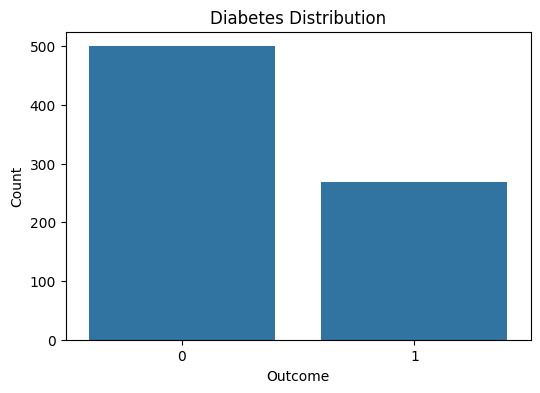

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(x='Outcome', data=df)

plt.title('Diabetes Distribution')
plt.xlabel('Outcome')
plt.ylabel('Count')

plt.show()

In [11]:
df['BMI_Age'] = df['BMI'] * df['Age']

df[['BMI','Age','BMI_Age']].head()

,BMI,Age,BMI_Age
0,33.6,50,1680.0
1,26.6,31,824.6
2,23.3,32,745.6
3,28.1,21,590.1
4,43.1,33,1422.3


In [12]:
X = df.drop('Outcome', axis=1)

y = df['Outcome']

print(X.shape)
print(y.shape)

(768, 9)
(768,)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Scaling Complete")

Scaling Complete


In [15]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Trained Successfully")

Logistic Regression Trained Successfully


In [16]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(name, y_true, y_pred):

    print("\n", "="*40)
    print(name)
    print("="*40)

    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))
    print("ROC-AUC  :", roc_auc_score(y_true, y_pred))

evaluate_model("Logistic Regression", y_test, lr_pred)
evaluate_model("Decision Tree", y_test, dt_pred)
evaluate_model("Random Forest", y_test, rf_pred)


Logistic Regression
Accuracy : 0.7532467532467533
Precision: 0.6491228070175439
Recall   : 0.6727272727272727
F1 Score : 0.6607142857142857
ROC-AUC  : 0.7353535353535354

Decision Tree
Accuracy : 0.7142857142857143
Precision: 0.5846153846153846
Recall   : 0.6909090909090909
F1 Score : 0.6333333333333333
ROC-AUC  : 0.7090909090909091

Random Forest
Accuracy : 0.7532467532467533
Precision: 0.6491228070175439
Recall   : 0.6727272727272727
F1 Score : 0.6607142857142857
ROC-AUC  : 0.7353535353535354


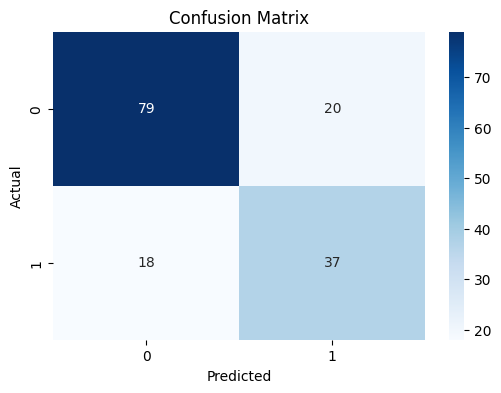

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

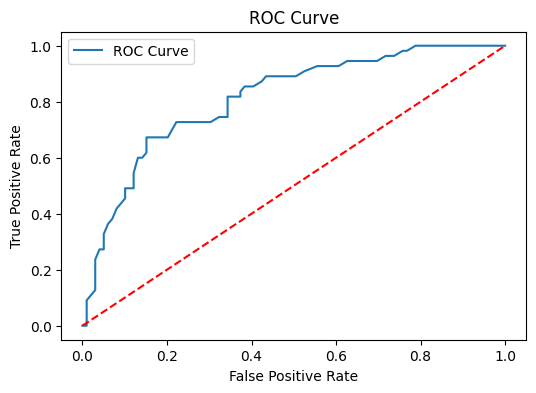

In [20]:
from sklearn.metrics import roc_curve

y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr, label='ROC Curve')
plt.plot([0,1],[0,1],'r--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.show()

In [21]:
importance = pd.DataFrame({
    'Feature': [
        'Pregnancies',
        'Glucose',
        'BloodPressure',
        'SkinThickness',
        'Insulin',
        'BMI',
        'DiabetesPedigreeFunction',
        'Age',
        'BMI_Age'
    ],
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
1,Glucose,0.255302
8,BMI_Age,0.165373
5,BMI,0.126600
6,DiabetesPedigreeFunction,0.105370
7,Age,0.104086
2,BloodPressure,0.072396
4,Insulin,0.062246
0,Pregnancies,0.055118
3,SkinThickness,0.053508


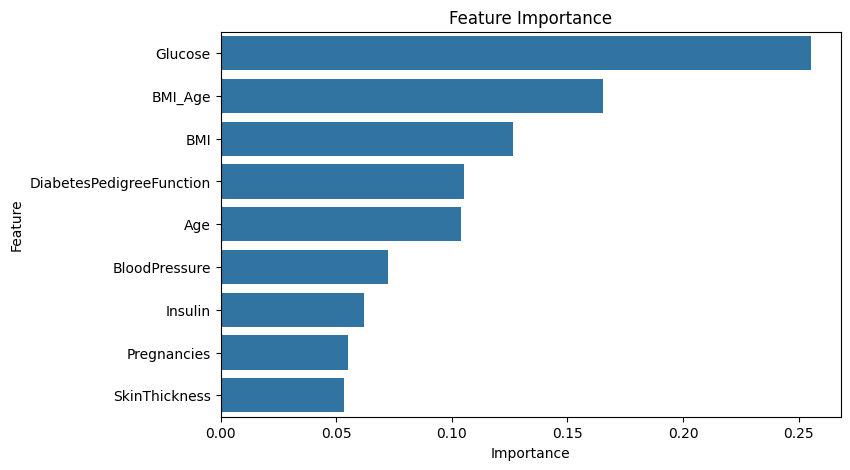

In [22]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title('Feature Importance')

plt.show()

In [23]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators':[100,200],
    'max_depth':[5,10,None]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

print("\nBest Cross Validation Score:")
print(grid.best_score_)

Best Parameters:
{'max_depth': 5, 'n_estimators': 200}

Best Cross Validation Score:
0.7736638677862189


In [24]:
!pip freeze > requirements.txt

In [25]:
from google.colab import files

files.download('requirements.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>